# ❤️ Heart Disease Prediction — Random Forest Classifier
**Dataset:** Heart Statlog Cleveland Hungary Final  
**Target:** `1` = Heart Disease, `0` = No Heart Disease

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## 2. Load & Explore the Dataset

In [2]:
df = pd.read_csv('heart_statlog_cleveland_hungary_final.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1190, 12)


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [3]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [4]:
print('Descriptive Statistics:')
df.describe()

Descriptive Statistics:


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


Missing Values:
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Target class distribution:
target
1    629
0    561
Name: count, dtype: int64


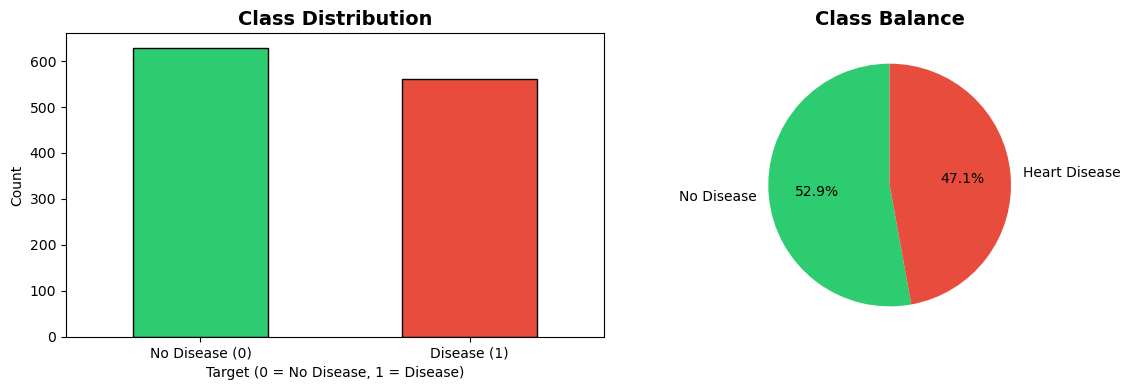

In [5]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTarget class distribution:')
print(df['target'].value_counts())

# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution bar
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target (0 = No Disease, 1 = Disease)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['No Disease', 'Heart Disease'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Correlation Heatmap

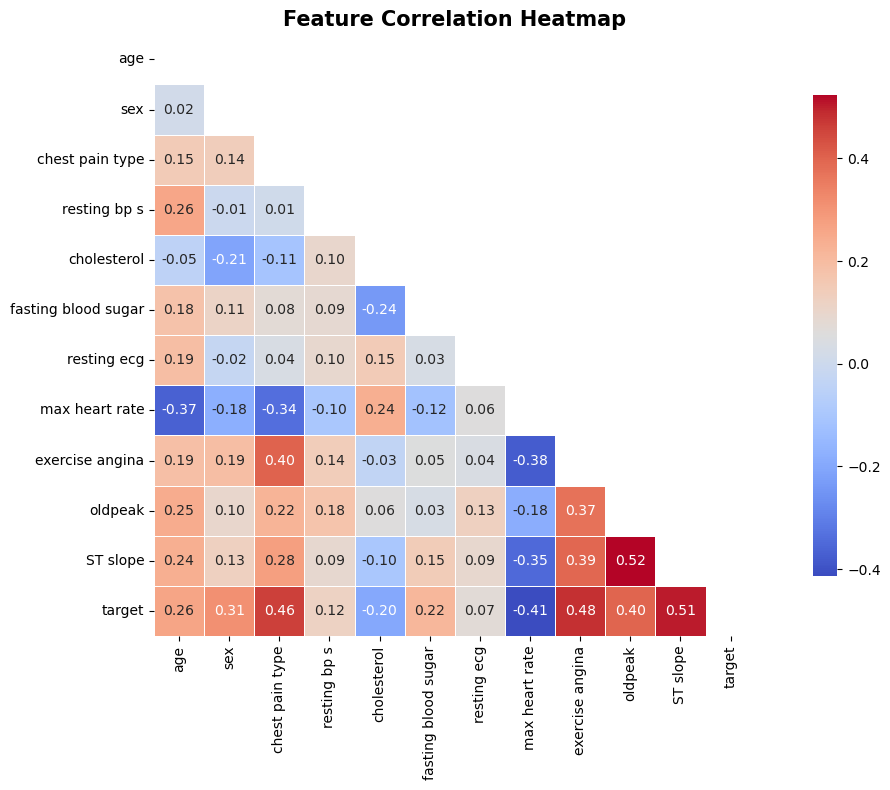

In [6]:
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Prepare Features & Target

In [7]:
X = df.drop('target', axis=1)
y = df['target']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nFeature columns:\n{list(X.columns)}')

Features shape : (1190, 11)
Target shape   : (1190,)

Feature columns:
['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol', 'fasting blood sugar', 'resting ecg', 'max heart rate', 'exercise angina', 'oldpeak', 'ST slope']


## 5. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class ratio in both splits
)

print(f'Training samples   : {X_train.shape[0]}')
print(f'Testing samples    : {X_test.shape[0]}')
print(f'\nTrain target distribution:\n{y_train.value_counts()}')
print(f'\nTest target distribution:\n{y_test.value_counts()}')

Training samples   : 952
Testing samples    : 238

Train target distribution:
target
1    503
0    449
Name: count, dtype: int64

Test target distribution:
target
1    126
0    112
Name: count, dtype: int64


## 6. Train Random Forest Model

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,       # number of trees
    max_depth=15,         # grow full trees
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',    # sqrt(n_features) per split — standard for classification
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

rf_model.fit(X_train, y_train)
print('Model training complete ✅')

Model training complete ✅


## 7. Predictions & Accuracy

In [17]:
y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_proba)

print('=' * 40)
print(f'  Training Accuracy : {train_acc * 100:.2f}%')
print(f'  Test Accuracy     : {test_acc  * 100:.2f}%')
print(f'  ROC-AUC Score     : {roc_auc:.4f}')
print('=' * 40)

  Training Accuracy : 100.00%
  Test Accuracy     : 92.44%
  ROC-AUC Score     : 0.9761


## 8. Classification Report

In [18]:
print('Classification Report:')
print('=' * 55)
print(classification_report(y_test, y_pred,
      target_names=['No Disease (0)', 'Heart Disease (1)']))

Classification Report:
                   precision    recall  f1-score   support

   No Disease (0)       0.92      0.92      0.92       112
Heart Disease (1)       0.93      0.93      0.93       126

         accuracy                           0.92       238
        macro avg       0.92      0.92      0.92       238
     weighted avg       0.92      0.92      0.92       238



## 9. Confusion Matrix

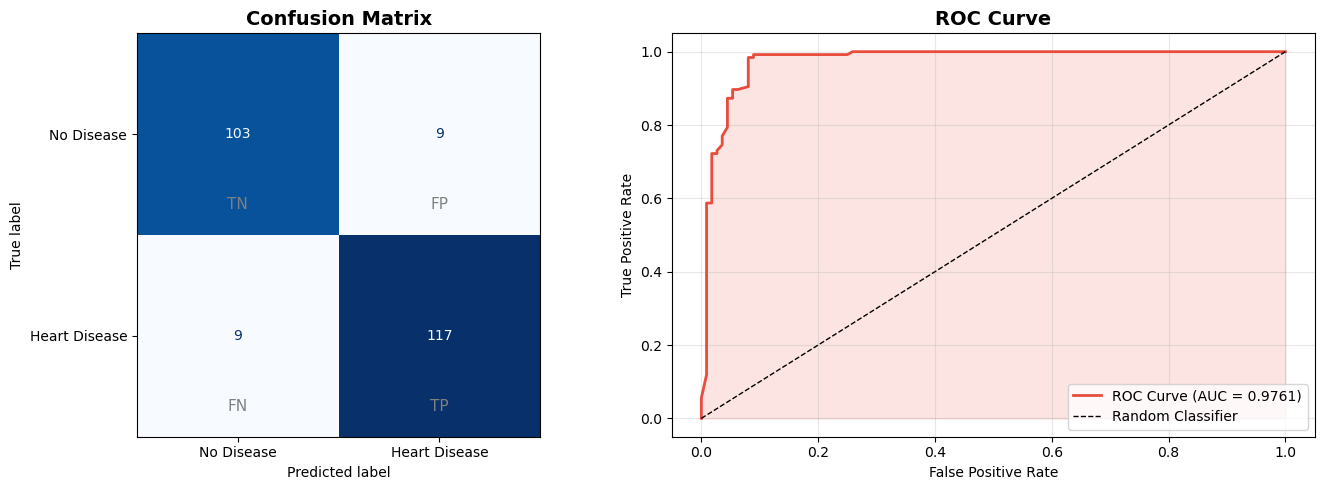

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Disease', 'Heart Disease'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Annotate TP/TN/FP/FN
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i + 0.35, labels[i][j],
                     ha='center', va='center', color='grey', fontsize=11)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Feature Importance

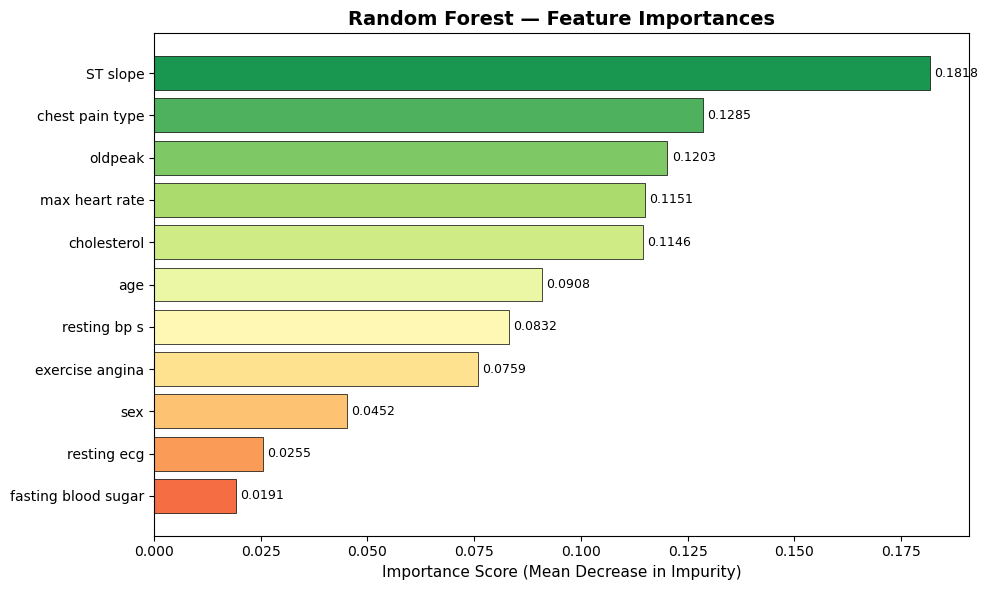


Top 5 most important features:
ST slope           0.181790
chest pain type    0.128492
oldpeak            0.120290
max heart rate     0.115101
cholesterol        0.114626
dtype: float64


In [20]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
bars = plt.barh(importances.index, importances.values, color=colors, edgecolor='black', linewidth=0.5)

# Add value labels
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=11)
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(importances.sort_values(ascending=False).head())

## 11. Cross-Validation (Stratified K-Fold)

5-Fold Cross-Validation Results:
  Accuracy per fold : [92.02 92.44 94.54 92.86 94.96]
  Mean Accuracy     : 93.36% ± 1.17%
  Mean ROC-AUC      : 0.9677 ± 0.0051


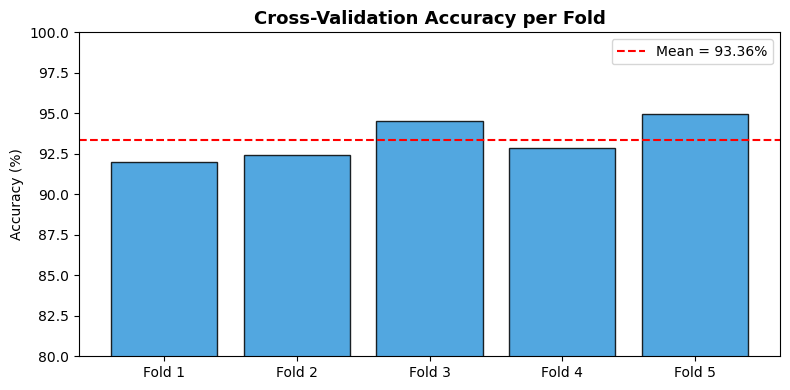

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
cv_auc    = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')

print('5-Fold Cross-Validation Results:')
print('=' * 45)
print(f'  Accuracy per fold : {np.round(cv_scores * 100, 2)}')
print(f'  Mean Accuracy     : {cv_scores.mean() * 100:.2f}% ± {cv_scores.std() * 100:.2f}%')
print(f'  Mean ROC-AUC      : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print('=' * 45)

# Plot CV scores
plt.figure(figsize=(8, 4))
folds = [f'Fold {i+1}' for i in range(5)]
plt.bar(folds, cv_scores * 100, color='#3498db', edgecolor='black', alpha=0.85)
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.ylim(80, 100)
plt.ylabel('Accuracy (%)')
plt.title('Cross-Validation Accuracy per Fold', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Summary

In [22]:
print('╔══════════════════════════════════════════╗')
print('║     RANDOM FOREST — FINAL RESULTS        ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Training Accuracy    : {train_acc*100:>6.2f}%          ║')
print(f'║  Test Accuracy        : {test_acc*100:>6.2f}%          ║')
print(f'║  ROC-AUC (Test)       : {roc_auc:>6.4f}           ║')
print(f'║  CV Mean Accuracy     : {cv_scores.mean()*100:>6.2f}%          ║')
print(f'║  CV Mean ROC-AUC      : {cv_auc.mean():>6.4f}           ║')
print('╚══════════════════════════════════════════╝')

╔══════════════════════════════════════════╗
║     RANDOM FOREST — FINAL RESULTS        ║
╠══════════════════════════════════════════╣
║  Training Accuracy    : 100.00%          ║
║  Test Accuracy        :  92.44%          ║
║  ROC-AUC (Test)       : 0.9761           ║
║  CV Mean Accuracy     :  93.36%          ║
║  CV Mean ROC-AUC      : 0.9677           ║
╚══════════════════════════════════════════╝
